# Chapter 2. Why does the first join on Kalpa's Q2 report nearly twice the bookings as collected, and how do we attach payments so that nothing counts twice?

**Week 2, Tuesday · Chapter 2 of 6 · Booked against collected.**

> **The client asks.** "Booked revenue is not collected revenue. Some orders are paid in two
> instalments, some are refunded, some were never paid at all. Show me, order by order, what we
> actually collected against what we booked in Q2. If there is a gap, I want to know which orders
> and which channel."
>
> Anand Iyer, finance controller, Kalpa Retail

The data platform lead added the payments table to the team's access and said, in passing, that
the payments feed "sometimes double-posts when the gateway retries".

**Who needs the answer.** Anand, who would read a collected figure twice his books as a quarter of collections running ahead and stand his collections team down; the data platform lead, who hears about a wrong number from the warehouse before anyone else does; and you, because the way chosen here carries every later chapter of the day.

**The questions on the way.**
1. Which Kalpa orders own two payment rows, and why?
2. What does a first draft of collected report for Q2?
3. Why is the first draft wrong when every row on it is right?
4. Which of four ways stops the double count, and what does each cost on this data?
5. Does the chosen way keep 462 orders and Rs 9,84,00,000 booked?
6. Do the two tables, each summed alone, agree with the fixed join?

**The metric at stake.** Collected revenue for Q2 against booked revenue for Q2. Booked is every Q2 order at its amount, whatever its status, Rs 9,84,00,000 over 462 orders, and collected can never honestly exceed it.

**What came before, and what this adds.** Chapter 1 traced five invented orders and seven invented payments. The LEFT JOIN with orders first was the only join that kept every booked order, and it still listed two orders twice: T-2, paid in two instalments, and T-3, whose payment the gateway posted twice, so seven lines described five orders. This chapter runs the same join on Kalpa's Q2 and reads a total from it.

**Setup.** The next cell finds the helper, connects to the warehouse and prepares the invented tables
of chapter 1, which this chapter uses once to show a mechanism. Every query below is also in
`sql/C2_W02_D02_02_why_twice_booked_STUDENT.sql`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
from decimal import Decimal

TINY = """DROP TABLE IF EXISTS tiny_orders, tiny_payments;
CREATE TEMP TABLE tiny_orders (
    order_id  text PRIMARY KEY,
    channel   text NOT NULL,
    amount    numeric(12, 2) NOT NULL
);
CREATE TEMP TABLE tiny_payments (
    payment_id    text PRIMARY KEY,
    order_id      text NOT NULL,
    paid_date     date NOT NULL,
    amount        numeric(12, 2) NOT NULL,
    instalment_no integer NOT NULL
);
INSERT INTO tiny_orders VALUES
    ('T-1', 'app',   1000),
    ('T-2', 'web',   2000),
    ('T-3', 'store', 1500),
    ('T-4', 'app',    800),
    ('T-5', 'store',  500);
INSERT INTO tiny_payments VALUES
    ('P-1', 'T-1', '2026-07-03', 1000, 1),
    ('P-2', 'T-2', '2026-07-05', 1200, 1),
    ('P-3', 'T-2', '2026-08-05',  800, 2),
    ('P-4', 'T-3', '2026-07-09', 1500, 1),
    ('P-5', 'T-3', '2026-07-09', 1500, 1),
    ('P-6', 'T-5', '2026-07-12',  500, 1),
    ('P-7', 'T-9', '2026-07-14',  600, 1);"""

conn = kit.connect()
conn.autocommit = True
with conn.cursor() as cur:
    cur.execute(TINY)            # invented, TEMP, so they vanish when this notebook stops


def run(query, params=None):
    """Run a query on this notebook's one connection and return its rows as dictionaries."""
    return kit.sql(query, params, conn=conn)


def one(query, params=None):
    """The first value of the first row, for a query that returns a single number."""
    row = run(query, params)[0]
    return next(iter(row.values()))


def show(rows, caption="", money=()):
    """Rows as the kit's table; columns named in money print as rupees."""
    if not rows:
        return kit.table(["result"], [["no rows"]], caption)
    heads = list(rows[0])
    body = []
    for r in rows:
        line = []
        for h in heads:
            v = r[h]
            if v is None:
                line.append("NULL")
            elif h in money:
                line.append(kit.rupees(v))
            elif isinstance(v, Decimal):
                line.append(f"{int(v):,}" if v == v.to_integral_value() else f"{float(v):,.2f}")
            else:
                line.append(str(v))
        body.append(line)
    kit.table(heads, body, caption)

booked_q2 = run("""
SELECT count(*) AS orders, sum(amount) AS booked
FROM orders
WHERE quarter = 'Q2'""")[0]
print(f'Q2 books {booked_q2["orders"]} orders and {kit.rupees(booked_q2["booked"])}, '
      "counted from the orders table alone, as on Monday.")

Q2 books 462 orders and Rs 9,84,00,000, counted from the orders table alone, as on Monday.


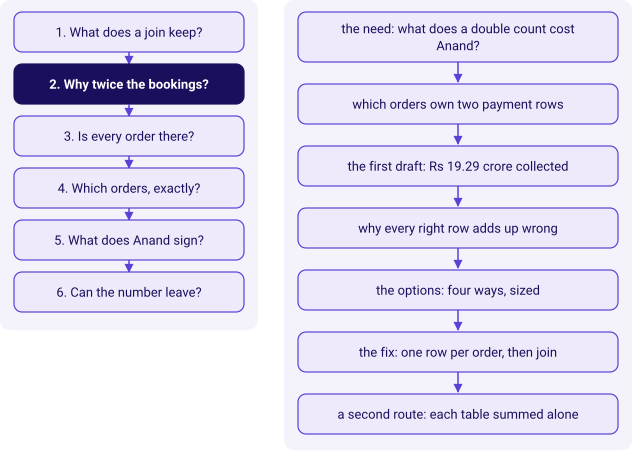

In [2]:
kit.side_by_side(
    kit.ladder(['What does a join keep?', 'Why twice the bookings?', 'Is every order there?', 'Which orders, exactly?', 'What does Anand sign?', 'Can the number leave?'], lit=1, show=False),
    kit.vflow(['the need: what does a double count cost Anand?', 'which orders own two payment rows', 'the first draft: Rs 19.29 crore collected', 'why every right row adds up wrong', 'the options: four ways, sized', 'the fix: one row per order, then join', 'a second route: each table summed alone'], show=False),
)

## What does Anand lose if collected is counted twice?

A finance controller reads collected against booked to decide where his collections team spends
the next week. If collected comes out above booked, the sentence that follows is "we are collecting
ahead of bookings", and the team is stood down in the very quarter Anand is asking about. If a
figure twice his books ever reaches Meera Raghavan, the CEO, in the Monday pack, it has to be
withdrawn in front of her, and every later number from the warehouse is read with doubt. The cost
of this chapter's mistake is the week of collections work lost and the trust spent. The retail story behind Anand's role, how a sale becomes cash and who checks it, is in the domain dossier, `content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, sections 3 and 4.

**Who else faces this.** Shopify creates a transaction "for every order that results in an
exchange of money", and one order can carry several: an authorization, which is money the customer
has agreed to pay, a capture of that same money, a sale, a void or a refund (Shopify developer
documentation, the REST Admin API's Transaction resource, checked 30 Sep 2026).
A report that adds every transaction of an order counts an authorised and captured payment twice.
dbt Labs names the mechanism in its MetricFlow documentation: "Fan-out joins are when one row in a
table is joined to multiple rows in another table, resulting in more output rows than input rows",
and MetricFlow "restricts the use of fan-out and chasm joins" (docs.getdbt.com, Joins, last updated
8 Sep 2026, checked 30 Sep 2026).

## 1. Which Kalpa orders own two payment rows, and why?

Chapter 1 found that an order id holds up to two payment rows in the warehouse. Which orders are
they?

**Predict before you run.** Among Q2's ten largest orders, how many carry two payment rows?
a) none, large orders are paid once; b) all ten, with instalments 1 and 2; c) the cancelled ones
only; d) about half, at random.

rank by amount,channel,status,payment rows,instalments
1,app,delivered,2,1 and 2
2,store,delivered,2,1 and 2
3,store,delivered,2,1 and 2
4,app,returned,2,1 and 2
5,store,delivered,2,1 and 2
6,web,delivered,2,1 and 2
7,app,delivered,2,1 and 2
8,app,delivered,2,1 and 2
9,app,delivered,2,1 and 2
10,store,cancelled,2,1 and 2


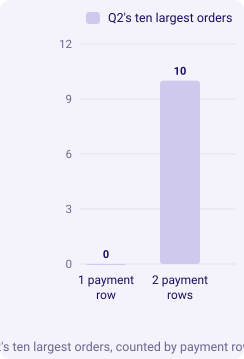

In [3]:
largest = run("""
SELECT o.order_id, o.channel, o.status, o.amount AS booked,
       count(p.payment_id) AS payment_rows,
       string_agg(p.instalment_no::text, ' and ' ORDER BY p.instalment_no) AS instalments
FROM orders o
LEFT JOIN payments p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'
GROUP BY o.order_id, o.channel, o.status, o.amount
ORDER BY o.amount DESC
LIMIT 10""")
show([{"rank by amount": i, "channel": r["channel"], "status": r["status"],
        "payment rows": r["payment_rows"], "instalments": r["instalments"]} for i, r in enumerate(largest, 1)],
     "Q2's ten largest orders and their payment rows")
kit.columns(["1 payment row", "2 payment rows"],
            [("Q2's ten largest orders", [sum(1 for r in largest if r["payment_rows"] == 1),
                                         sum(1 for r in largest if r["payment_rows"] == 2)])],
            title="Q2's ten largest orders, counted by payment rows")

**What happened.** The answer is b. Every one of Q2's ten largest orders carries two payment rows,
instalment 1 and instalment 2: large business invoices at Kalpa are settled in two parts, as Anand
said, so each order owns two payment rows and comes out of a join twice.

In [4]:
kit.check("each of the ten largest Q2 orders carries two payment rows",
          all(r["payment_rows"] == 2 for r in largest), f'{len(largest)} orders')
kit.check("every one of the ten is paid in instalments 1 and 2",
          all(r["instalments"] == "1 and 2" for r in largest), "instalments 1 and 2")

## 2. What does a first draft of collected report for Q2?

**The plausible wrong answer.** A teammate writes the first draft. It keeps every Q2 order, as
chapter 1 taught, with a LEFT JOIN to `payments`, and it counts an order as collected, at its booked
amount, whenever a payment row sits beside it. `FILTER (WHERE ...)`, which Monday used, restricts one
aggregate to the rows that meet a condition.

```sql
SELECT count(*)                                              AS rows_out,
       sum(o.amount) FILTER (WHERE p.payment_id IS NOT NULL) AS collected
FROM orders o
LEFT JOIN payments p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2';
```

**Predict before you run.** Against Rs 9,84,00,000 booked, what does the draft report as collected?
a) a little under Rs 9.84 crore, since some orders may be unpaid; b) exactly Rs 9.84 crore;
c) about Rs 19.3 crore; d) about Rs 4.9 crore.

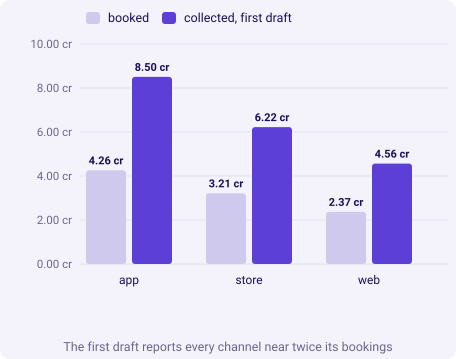

In [5]:
draft = run("""
SELECT count(*)                                              AS rows_out,
       sum(o.amount) FILTER (WHERE p.payment_id IS NOT NULL) AS collected
FROM orders o
LEFT JOIN payments p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'""")[0]
kit.stats([(kit.rupees(draft["collected"]), "collected, first draft", "the order amount beside each payment row"),
           (kit.rupees(booked_q2["booked"]), "booked", "Monday's number, orders alone"),
           (f'{draft["collected"] / booked_q2["booked"]:.2f} x', "collected over booked", "which cannot be")])
by_ch = run("""
SELECT o.channel,
       count(*)                                              AS rows_out,
       sum(o.amount) FILTER (WHERE p.payment_id IS NOT NULL) AS collected
FROM orders o
LEFT JOIN payments p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'
GROUP BY o.channel
ORDER BY o.channel""")
bk_ch = {r["channel"]: r for r in run("""
SELECT channel, count(*) AS orders, sum(amount) AS booked
FROM orders
WHERE quarter = 'Q2'
GROUP BY channel
ORDER BY channel""")}
kit.columns([r["channel"] for r in by_ch],
            [("booked", [float(bk_ch[r["channel"]]["booked"]) / 1e7 for r in by_ch]),
             ("collected, first draft", [float(r["collected"]) / 1e7 for r in by_ch])],
            fmt=lambda v: f"{v:.2f} cr", title="The first draft reports every channel near twice its bookings")

**What happened.** The answer is c: Rs 19,29,04,410 collected against Rs 9,84,00,000 booked, 1.96
times, and every channel sits near twice its bookings. Read as it stands, the draft says Kalpa
collected Rs 9.45 crore more than it sold, and a finance controller who believes it stops chasing
anything this quarter.

## 3. Why is the first draft wrong when every row on it is right?

**Why it is wrong.** Every row of the draft is a real order beside a real payment, and no row is
wrong. The error lives in the sum: an order that owns two payment rows is written twice, and its
booked amount rides along on both rows, so `sum(o.amount)` counts it twice. A sum over a join is a
sum at the join's grain, which here is the payment, whatever column it names. This is a fan-out: a
key that repeats on one side multiplies the rows of the other.

**The check that catches it.** Two checks, and either one is enough. Count the rows the join returns
against the orders that went in, and compare collected with booked, since cash against bookings can
never honestly exceed them.

order_id,booked,payment_id,instalment_no,paid
KR-00595,"Rs 4,01,000",P-00861,1,"Rs 2,40,600"
KR-00595,"Rs 4,01,000",P-00862,2,"Rs 1,60,400"


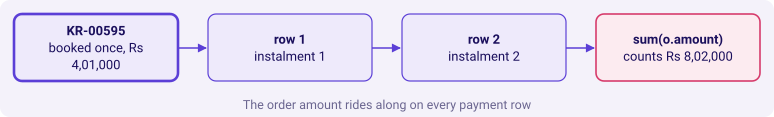

In [6]:
kr595 = run("""
SELECT o.order_id, o.amount AS booked, p.payment_id, p.instalment_no, p.amount AS paid
FROM orders o
JOIN payments p ON p.order_id = o.order_id
WHERE o.order_id = 'KR-00595'
ORDER BY p.instalment_no""")
show(kr595, "KR-00595, one order, two payment rows after the join", money=["booked", "paid"])
kit.flow(["KR-00595\nbooked once, Rs 4,01,000", "row 1\ninstalment 1", "row 2\ninstalment 2",
          "sum(o.amount)\ncounts Rs 8,02,000"], kinds=["known", "plain", "plain", "bad"],
         title="The order amount rides along on every payment row")
kit.check("the join returns more rows than Q2 has orders", draft["rows_out"] > booked_q2["orders"],
          f'{booked_q2["orders"]} orders in, {draft["rows_out"]} rows out')
kit.check("the draft's collected exceeds booked, which cash cannot do",
          draft["collected"] > booked_q2["booked"], f'{draft["collected"] / booked_q2["booked"]:.2f} times')
kit.check("KR-00595 alone is summed twice by the draft",
          sum(r["booked"] for r in kr595) == 2 * kr595[0]["booked"], kit.rupees(2 * kr595[0]["booked"]))

## Which of four ways stops the double count, and what does each cost on this data?

The doubling has two possible sources, and a fix has to say which one it removes: legitimate second
instalments, which are real cash, and repeated postings of one payment, which the platform lead
warned about. Four ways a team could stop the double count:

| Option | How it works | What it assumes |
|---|---|---|
| A. Bring payments to one row per order, then join | A CTE sums each order's payment rows into one row, `posted`, and keeps `payment_rows`; the LEFT JOIN then meets orders at their own grain | Nothing beyond the key |
| B. DISTINCT after the join | `sum(DISTINCT o.amount)` adds each different amount once | That no two orders share an amount |
| C. A window dedupe | Keep the first posting of each order and instalment with a window function, which Wednesday teaches | That a repeat of the same instalment is a retry |
| D. Fix the feed | The platform lead makes the gateway post a retried payment once, with an idempotency key | Weeks of platform work, and nothing done to Q2 as posted |

The cell below runs A and B on Kalpa's Q2 and times them; C needs a tool this room meets tomorrow and
D is a request, so their columns say what each would do.

Option,Rows out for 462 orders,Booked after it,Error against booked,Time
"A. one row per order, then join",462,"Rs 9,84,00,000",Rs 0,2.5 ms
B. sum(DISTINCT o.amount),"678, one sum","Rs 9,63,67,220","-Rs 20,32,780",1.1 ms
C. window dedupe,more than 462,still inflated,every two-instalment order keeps two rows,needs Wednesday's tool
D. fix the feed,no change to Q2,no change,Q2 stays as posted,weeks of platform work


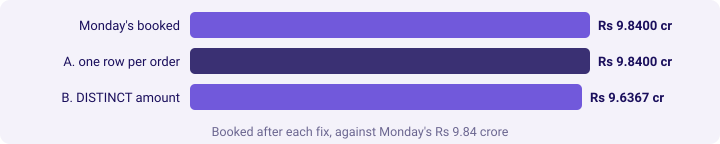

243 of Q2's 462 orders share their amount with another order, across 97 amounts that repeat.


In [7]:
import time
t0 = time.perf_counter()
fixed = run("""
WITH posted_per_order AS (
    SELECT order_id, sum(amount) AS posted, count(*) AS payment_rows
    FROM payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, pp.posted, pp.payment_rows
FROM orders o
LEFT JOIN posted_per_order pp ON pp.order_id = o.order_id
WHERE o.quarter = 'Q2'""")
t_a = time.perf_counter() - t0
t0 = time.perf_counter()
opt_b = run("""
SELECT count(*) AS rows_out, sum(DISTINCT o.amount) AS booked_distinct
FROM orders o
LEFT JOIN payments p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'""")[0]
t_b = time.perf_counter() - t0
shared = run("""
SELECT count(*) AS orders_sharing_an_amount, count(DISTINCT amount) AS distinct_amounts
FROM orders o
WHERE quarter = 'Q2'
  AND (SELECT count(*) FROM orders o2 WHERE o2.quarter = 'Q2' AND o2.amount = o.amount) > 1""")[0]
booked_a = sum(r["booked"] for r in fixed)
kit.table(["Option", "Rows out for 462 orders", "Booked after it", "Error against booked", "Time"],
          [("A. one row per order, then join", len(fixed), kit.rupees(booked_a),
            kit.rupees(booked_a - booked_q2["booked"]), f"{t_a * 1000:.1f} ms"),
           ("B. sum(DISTINCT o.amount)", f'{opt_b["rows_out"]}, one sum', kit.rupees(opt_b["booked_distinct"]),
            kit.rupees(opt_b["booked_distinct"] - booked_q2["booked"]), f"{t_b * 1000:.1f} ms"),
           ("C. window dedupe", "more than 462", "still inflated", "every two-instalment order keeps two rows",
            "needs Wednesday's tool"),
           ("D. fix the feed", "no change to Q2", "no change", "Q2 stays as posted", "weeks of platform work")],
          caption="Four ways to stop the double count, sized on Kalpa's Q2")
kit.bars([("Monday's booked", float(booked_q2["booked"]) / 1e7), ("A. one row per order", float(booked_a) / 1e7),
          ("B. DISTINCT amount", float(opt_b["booked_distinct"]) / 1e7)], lit=[1],
         fmt=lambda v: f"Rs {v:.4f} cr", title="Booked after each fix, against Monday's Rs 9.84 crore")
print(f'{shared["orders_sharing_an_amount"]} of Q2\'s 462 orders share their amount with another order, '
      f'across {shared["distinct_amounts"]} amounts that repeat.')

**The best-fit call.** Option A. It returns one row for each of the 462 orders with booked exactly
Monday's figure, it keeps every order whether paid or not, and it keeps `payment_rows`, so a
repeated posting stays visible for chapter 4 instead of vanishing. B looks as if it works and loses
Rs 20,32,780 of real bookings, because DISTINCT removes repeated values and a repeated value is not
a repeated order: 243 of the 462 orders share their amount with another. C removes only repeats of
the same instalment, so every order paid in two instalments still comes out twice and the draft
stays inflated. D is the right request to make of the platform lead, and it changes nothing about
the quarter Anand asked for. Both A and B take a few milliseconds, so the choice is about what each
gets wrong.

**The fact that would change the call.** A feed that carried the gateway's own transaction reference
on every row, repeated on a retry, would let a DISTINCT on that reference remove retries before any
join, exactly. And if Anand asked per payment, say to match each line of the bank statement, the
payment would be the right grain and nothing would be summed first.

## 4. Does the chosen way keep 462 orders and Rs 9,84,00,000 booked?

```sql
WITH posted_per_order AS (
    SELECT order_id, sum(amount) AS posted, count(*) AS payment_rows
    FROM payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, pp.posted, pp.payment_rows
FROM orders o
LEFT JOIN posted_per_order pp ON pp.order_id = o.order_id
WHERE o.quarter = 'Q2';
```

`posted` is everything the feed holds against an order, instalments and any repeat alike, and an
order with no payment row gets NULL there.

**Predict before you run.** How many rows does it return? a) 678; b) 462; c) 216; d) 1,000.

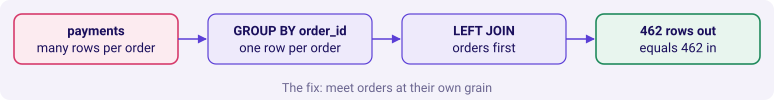

In [8]:
kit.stats([(f"{len(fixed)}", "rows out", "one per Q2 order"),
           (kit.rupees(booked_a), "booked after the join", "Monday's figure"),
           (f'{len({r["order_id"] for r in fixed})}', "distinct orders", "none repeated")])
kit.flow(["payments\nmany rows per order", "GROUP BY order_id\none row per order",
          "LEFT JOIN\norders first", "462 rows out\nequals 462 in"],
         kinds=["bad", "plain", "plain", "good"], title="The fix: meet orders at their own grain")
kit.check("the fixed join returns one row per Q2 order", len(fixed) == booked_q2["orders"],
          f'{len(fixed)} out, {booked_q2["orders"]} in')
kit.check("booked after the fixed join equals Monday's booked", booked_a == booked_q2["booked"],
          kit.rupees(booked_a))
kit.check("no order appears twice", len({r["order_id"] for r in fixed}) == len(fixed), f"{len(fixed)}")

**What happened.** The answer is b: 462 rows for 462 orders, and booked after the join is
Rs 9,84,00,000, Monday's figure to the rupee. What changed: the 216 extra rows are gone, and the
order amount is summed once per order. The `posted` column now holds what the feed recorded against
each order.

**Your turn.** Read the total yourself. In the empty cell below, type these lines and run it:

```python
posted_total = sum(r["posted"] for r in fixed if r["posted"] is not None)
print(kit.rupees(posted_total))
```

Write the figure down as "posted against Q2 orders". Chapter 3 asks what it is made of, and whether
it is the collected figure Anand asked for.

> **Kavya's review.** "A join is a multiplication until you prove it is not. Bring the many side to
> the grain of the question before you join, and show me rows in and rows out beside the total."

## Do the two tables, each summed alone, agree with the fixed join?

The second route never joins. Booked comes from `orders` alone; posted comes from `payments` alone,
restricted to Q2's order ids with `IN`, so no order can be counted twice by a join. If the fixed
join added or lost anything, one of the two would disagree with it.

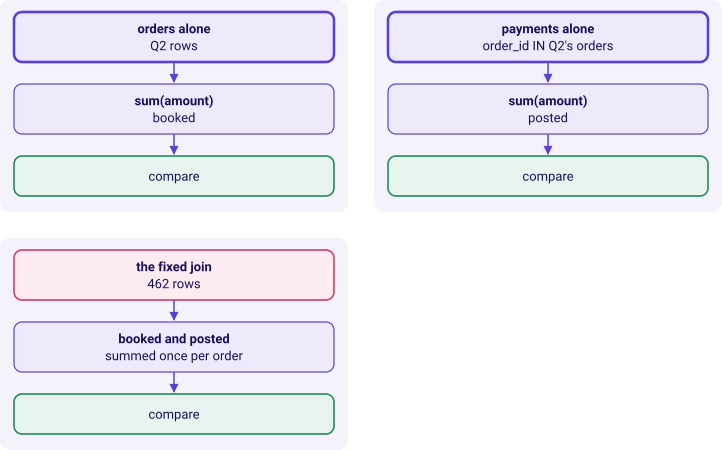

In [9]:
posted_alone = one("""
SELECT sum(amount) AS posted
FROM payments
WHERE order_id IN (SELECT order_id FROM orders WHERE quarter = 'Q2')""")
posted_join = sum(r["posted"] for r in fixed if r["posted"] is not None)
kit.side_by_side(
    kit.vflow(["orders alone\nQ2 rows", "sum(amount)\nbooked", "compare"],
              kinds=["known", "plain", "good"], show=False),
    kit.vflow(["payments alone\norder_id IN Q2's orders", "sum(amount)\nposted", "compare"],
              kinds=["known", "plain", "good"], show=False),
    kit.vflow(["the fixed join\n462 rows", "booked and posted\nsummed once per order", "compare"],
              kinds=["bad", "plain", "good"], show=False),
)
kit.check("booked from orders alone equals booked after the fixed join", booked_a == booked_q2["booked"],
          kit.rupees(booked_q2["booked"]))
kit.check("posted from payments alone equals posted after the fixed join", posted_alone == posted_join,
          "equal to the rupee")

**What happened.** Both routes agree: booked is Rs 9,84,00,000 by each, and posted from `payments`
alone equals the fixed join's posted to the rupee. The second route would catch a fan-out the first
missed, because it sums each table at its own grain and never multiplies anything.

### [F] Revenue doubled after a join and every row looks fine: where do you look?

At the grain, not at the rows. Each row is right, and the sum runs at the join's grain, so the first
question is which key repeats on the many side. Count rows before and after the join, list the keys
that repeat with `GROUP BY key HAVING count(*) > 1` on the many side, then bring that side to the
key's grain in a CTE before joining, and prove it with rows in equal to rows out and the total
recomputed from the source table alone.

### [S] Your join grew the row count: name the cause and the check.

The cause is a key that is unique on one side and repeats on the other, usually a one-to-many
relationship read as one-to-one. The check is the count before and after the join, plus a count of
the repeated keys on the many side; the growth must equal the extra rows those keys explain, or
something else is wrong too.

### Depth: why is SUM(DISTINCT ...) a tempting fix that fails?

It makes the doubled number go away, which feels like proof. It removes repeated values, and two
different orders of the same amount are two orders: on Kalpa's Q2 it loses Rs 20,32,780 of real
bookings. It would also remove a genuine second payment that happened to match the first. A fix
that works on the grain says which rows it merged and why; DISTINCT cannot say either.

## What did this chapter answer, one line per question?

1. Kalpa's large business invoices are paid in two instalments, so every one of Q2's ten largest
   orders owns two payment rows, instalment 1 and instalment 2.
2. The first draft reports Rs 19,29,04,410 collected against Rs 9,84,00,000 booked, 1.96 times.
3. It is wrong because the order amount rides on every payment row, so 462 orders become 678 rows
   and the sum runs at the payment's grain.
4. Bringing payments to one row per order before the join is the best fit; DISTINCT loses
   Rs 20,32,780 of bookings, a window dedupe leaves the instalments doubled, and a feed fix changes
   nothing about Q2.
5. The fixed join returns 462 rows and Rs 9,84,00,000 booked, Monday's figures exactly.
6. Each table summed alone agrees with it, for booked and for posted.

**The question this leaves.** The fixed join keeps every order, and its `posted` column is what the
feed recorded. Is every booked order still there when the report is written, and what, rupee by
rupee, separates booked from posted? That is chapter 3.

In [10]:
kit.check_summary()